<a href="https://colab.research.google.com/github/Superromz/LeadershipRecommenderLAU/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Feature Engineering, Baseline Models, and Candidate Model Training

**Project:** Leadership Style Coach — University Edition  
**Author:** Romero Habib  
**Supervisor:** Dr. Rachad  
**Institution:** Lebanese American University (LAU), School of Arts and Sciences  

---

## Purpose

This notebook covers Phase 1 of the project pipeline (Weeks 1–2), specifically:

1. Loading and verifying the dataset
2. Feature engineering — encoding categorical variables and defining the feature matrix and target
3. Training and evaluating three required baseline classifiers: majority-class, logistic regression, and decision tree
4. Training and evaluating two candidate models: Random Forest and XGBoost
5. Comparing all five models against Hypothesis H1
6. Exporting the best-performing model and preprocessing pipeline for use in `03_explainability.ipynb` and the backend

## Research Hypothesis Being Tested

> **H1 — Classification Accuracy:** A supervised classification model trained on the Global Cultural Leadership Insights dataset can accurately classify a university student's dominant leadership style across four categories (Supportive, Transactional, Laissez-Faire, and Transformational), outperforming baseline classifiers including a majority-class classifier, logistic regression, and a decision tree.

## Primary Evaluation Metric

Due to class imbalance in the dataset (Supportive ≈ 40%, Transformational ≈ 14%), **macro-averaged F1 score** is used as the primary metric. This ensures that performance across all four classes is weighted equally, preventing the majority class from masking poor performance on minority classes. Accuracy is also reported for completeness.

---
## 1. Imports and Configuration

In [12]:

# ── Colab / Local Environment Setup ──────────────────────────────────────────
# Run this cell FIRST. It detects Google Colab, clones the repo, and sets
# the working directory so all relative paths (../data/, ../models/) work.

import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.system('pip install -q xgboost')

    REPO_URL  = 'https://github.com/Superromz/LeadershipRecommenderLAU.git'
    REPO_NAME = 'LeadershipRecommenderLAU'

    if not os.path.exists(f'/content/{REPO_NAME}'):
        os.system(f'git clone {REPO_URL}')
        print(f'Cloned repo to /content/{REPO_NAME}')
    else:
        os.system(f'cd /content/{REPO_NAME} && git pull origin main')
        print('Repo already cloned — pulled latest changes.')

    os.chdir(f'/content/{REPO_NAME}/notebooks')
    print(f'Working directory: {os.getcwd()}')
    print('Setup complete. Proceed to the next cell.')
else:
    print(f'Running locally. Working directory: {os.getcwd()}')


Cloned repo to /content/LeadershipRecommenderLAU
Working directory: /content/LeadershipRecommenderLAU/notebooks
Setup complete. Proceed to the next cell.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pickle
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)

# Output directories
os.makedirs('../models', exist_ok=True)
os.makedirs('../eda_outputs', exist_ok=True)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')

All libraries imported successfully.
NumPy 2.0.2 | Pandas 2.2.2


---
## 2. Data Loading and Verification

The dataset is the **Global Cultural Leadership Insights** dataset (`CrossCultural_Leadership_Dataset_5k_2.csv`). Per the EDA completed in `01_eda.ipynb`, the dataset contains 6,945 rows, 21 columns, and zero missing values.

The target variable is `Leadership_Behavior_Encoded`, which encodes the four leadership style classes:  
- **0** = Laissez-Faire (1,411 instances)  
- **1** = Supportive (2,802 instances)  
- **2** = Transactional (1,775 instances)  
- **3** = Transformational (957 instances)

In [14]:
df = pd.read_csv('../data/CrossCultural_Leadership_Dataset_5k_2.csv')

print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head(3)

Dataset shape: (6945, 21)
Missing values: 0


,Respondent_ID,Country,Age,Gender,Education_Level,Work_Experience_Years,Position_Level,Power_Distance,Individualism,Masculinity,...,Long_Term_Orientation,Indulgence,Role_Assumption,Production_Emphasis,Initiation_of_Structure,Tolerance_of_Uncertainty,Integration,Consideration,Preferred_Leadership_Behavior,Leadership_Behavior_Encoded
0,1,JPN,48,Male,Bachelor,2,Junior,49.237890,76.184855,79.109461,...,63.725145,81.127194,2,1,2,1,5,4,Supportive,1
1,2,NGA,37,Male,Master,17,Mid,33.799925,55.908143,46.509419,...,9.720500,0.471008,5,4,5,1,5,5,Transformational,3
2,3,IND,50,Female,Bachelor,11,Mid,58.183617,28.382884,43.504239,...,71.401878,68.590050,4,5,1,4,5,2,Transactional,2


In [15]:
# Verify class distribution
class_counts = df['Preferred_Leadership_Behavior'].value_counts()
class_pct = df['Preferred_Leadership_Behavior'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(1)
})
print('Target class distribution:')
print(class_summary)
print(f'\nMajority-class baseline accuracy (Supportive): {class_pct.max():.1f}%')

Target class distribution:
                               Count  Percentage (%)
Preferred_Leadership_Behavior                       
Supportive                      2802            40.3
Transactional                   1775            25.6
Laissez-Faire                   1411            20.3
Transformational                 957            13.8

Majority-class baseline accuracy (Supportive): 40.3%


---
## 3. Feature Engineering

### 3.1 Feature Selection

The following feature groups are used as inputs to the model:

| Group | Features |
|---|---|
| **Behavioural (Likert 1–5)** | Role_Assumption, Production_Emphasis, Initiation_of_Structure, Tolerance_of_Uncertainty, Integration, Consideration |
| **Cultural (Hofstede, 0–100)** | Power_Distance, Individualism, Masculinity, Uncertainty_Avoidance, Long_Term_Orientation, Indulgence |
| **Demographics** | Age, Work_Experience_Years, Gender, Education_Level, Position_Level, Country |

**Key finding from EDA:** The six behavioural features carry almost all of the predictive signal. The cultural and demographic features show negligible class separation. All features are retained here so that SHAP (Notebook 03) can confirm this empirically — this is an expected and confirmable result.

`Respondent_ID` is dropped as it is an identifier with no predictive value.  
`Preferred_Leadership_Behavior` is dropped as it is the string form of the target.

In [16]:
# Drop identifier and string target
df_model = df.drop(columns=['Respondent_ID', 'Preferred_Leadership_Behavior'])

# Define feature groups
BEHAVIOURAL_FEATURES = [
    'Role_Assumption', 'Production_Emphasis', 'Initiation_of_Structure',
    'Tolerance_of_Uncertainty', 'Integration', 'Consideration'
]

CULTURAL_FEATURES = [
    'Power_Distance', 'Individualism', 'Masculinity',
    'Uncertainty_Avoidance', 'Long_Term_Orientation', 'Indulgence'
]

NUMERIC_DEMO_FEATURES = ['Age', 'Work_Experience_Years']

CATEGORICAL_FEATURES = ['Country', 'Gender', 'Education_Level', 'Position_Level']

NUMERIC_FEATURES = BEHAVIOURAL_FEATURES + CULTURAL_FEATURES + NUMERIC_DEMO_FEATURES

TARGET = 'Leadership_Behavior_Encoded'

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nNumeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print(f'\nTarget classes: {sorted(y.unique())} → {dict(zip(sorted(y.unique()), ["Laissez-Faire", "Supportive", "Transactional", "Transformational"]))}')

Feature matrix shape: (6945, 18)
Target shape: (6945,)

Numeric features (14): ['Role_Assumption', 'Production_Emphasis', 'Initiation_of_Structure', 'Tolerance_of_Uncertainty', 'Integration', 'Consideration', 'Power_Distance', 'Individualism', 'Masculinity', 'Uncertainty_Avoidance', 'Long_Term_Orientation', 'Indulgence', 'Age', 'Work_Experience_Years']

Categorical features (4): ['Country', 'Gender', 'Education_Level', 'Position_Level']

Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → {np.int64(0): 'Laissez-Faire', np.int64(1): 'Supportive', np.int64(2): 'Transactional', np.int64(3): 'Transformational'}


### 3.2 Train/Test Split

An 80/20 stratified split is used. Stratification ensures that the class distribution is preserved in both the training and test sets, which is important given the class imbalance.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:     {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Class distribution in training set:')
print(y_train.value_counts().sort_index())
print()
print('Class distribution in test set:')
print(y_test.value_counts().sort_index())

Training set: 5556 rows (80.0%)
Test set:     1389 rows (20.0%)

Class distribution in training set:
Leadership_Behavior_Encoded
0    1129
1    2241
2    1420
3     766
Name: count, dtype: int64

Class distribution in test set:
Leadership_Behavior_Encoded
0    282
1    561
2    355
3    191
Name: count, dtype: int64


### 3.3 Preprocessing Pipeline

A `ColumnTransformer` is used to apply appropriate preprocessing to each feature type:

- **Numeric features** (behavioural, cultural, demographic): `StandardScaler` — required for logistic regression convergence; harmless for tree-based models
- **Categorical features** (Country, Gender, Education_Level, Position_Level): `OneHotEncoder` with `handle_unknown='ignore'` to handle unseen categories at inference time

This preprocessor is wrapped into each model's `Pipeline` so that feature encoding is reproducible and exportable as a single artifact.

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

# Fit on training data to inspect output shape
X_train_transformed = preprocessor.fit_transform(X_train)
print(f'Transformed training feature matrix shape: {X_train_transformed.shape}')

# Record feature names after one-hot encoding (needed for SHAP in notebook 03)
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + ohe_feature_names
print(f'Total features after encoding: {len(all_feature_names)}')
print(f'OHE features: {ohe_feature_names}')

Transformed training feature matrix shape: (5556, 30)
Total features after encoding: 30
OHE features: ['Country_BRA', 'Country_IND', 'Country_JPN', 'Country_NGA', 'Country_USA', 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Education_Level_Bachelor', 'Education_Level_High School', 'Education_Level_Master', 'Education_Level_PhD', 'Position_Level_Executive', 'Position_Level_Junior', 'Position_Level_Mid', 'Position_Level_Senior']


---
## 4. Model Training and Evaluation

### Evaluation Helper

A shared evaluation function is defined to compute and display consistent metrics across all models.

In [19]:
CLASS_NAMES = ['Laissez-Faire', 'Supportive', 'Transactional', 'Transformational']

results = {}  # Store all model results for comparison

def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, fit=True):
    """
    Fit (optional), predict, and evaluate a sklearn Pipeline.
    Stores results in the global `results` dict.
    Returns y_pred for downstream use.
    """
    if fit:
        pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)

    results[name] = {
        'Accuracy': round(acc, 4),
        'Macro Precision': round(prec, 4),
        'Macro Recall': round(rec, 4),
        'Macro F1': round(f1, 4)
    }

    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Macro Precision : {prec:.4f}')
    print(f'  Macro Recall    : {rec:.4f}')
    print(f'  Macro F1        : {f1:.4f}  ← primary metric')
    print()
    print(classification_report(y_te, y_pred, target_names=CLASS_NAMES, zero_division=0))

    return y_pred

print('Evaluation function defined.')

Evaluation function defined.


---
### 4.1 Baseline 1 — Majority-Class Classifier

The majority-class classifier always predicts the most frequent class (Supportive, ≈40%). This is the simplest possible baseline and establishes the floor that any meaningful model must exceed. Because it never predicts the three minority classes, its macro F1 will be substantially lower than its accuracy.

In [20]:
majority_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=42))
])

evaluate_model('Baseline: Majority-Class', majority_pipeline, X_train, y_train, X_test, y_test)


  Baseline: Majority-Class
  Accuracy        : 0.4039
  Macro Precision : 0.1010
  Macro Recall    : 0.2500
  Macro F1        : 0.1438  ← primary metric

                  precision    recall  f1-score   support

   Laissez-Faire       0.00      0.00      0.00       282
      Supportive       0.40      1.00      0.58       561
   Transactional       0.00      0.00      0.00       355
Transformational       0.00      0.00      0.00       191

        accuracy                           0.40      1389
       macro avg       0.10      0.25      0.14      1389
    weighted avg       0.16      0.40      0.23      1389



array([1, 1, 1, ..., 1, 1, 1])

---
### 4.2 Baseline 2 — Logistic Regression

Logistic regression is a standard linear baseline. `class_weight='balanced'` is applied to account for class imbalance. `max_iter=1000` is set to ensure convergence on this dataset.

In [21]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        multi_class='multinomial',
        solver='lbfgs'
    ))
])

evaluate_model('Baseline: Logistic Regression', lr_pipeline, X_train, y_train, X_test, y_test)


  Baseline: Logistic Regression
  Accuracy        : 0.9993
  Macro Precision : 0.9987
  Macro Recall    : 0.9993
  Macro F1        : 0.9990  ← primary metric

                  precision    recall  f1-score   support

   Laissez-Faire       1.00      1.00      1.00       282
      Supportive       1.00      1.00      1.00       561
   Transactional       1.00      1.00      1.00       355
Transformational       0.99      1.00      1.00       191

        accuracy                           1.00      1389
       macro avg       1.00      1.00      1.00      1389
    weighted avg       1.00      1.00      1.00      1389



array([1, 3, 3, ..., 2, 3, 2])

---
### 4.3 Baseline 3 — Decision Tree

A decision tree provides an interpretable non-linear baseline. `class_weight='balanced'` is applied. `max_depth` is left unconstrained to allow the tree to fully grow, matching the default behaviour typically assumed for a decision tree baseline.

In [22]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

evaluate_model('Baseline: Decision Tree', dt_pipeline, X_train, y_train, X_test, y_test)


  Baseline: Decision Tree
  Accuracy        : 0.7113
  Macro Precision : 0.7310
  Macro Recall    : 0.7180
  Macro F1        : 0.7234  ← primary metric

                  precision    recall  f1-score   support

   Laissez-Faire       0.75      0.66      0.70       282
      Supportive       0.68      0.74      0.71       561
   Transactional       0.67      0.64      0.65       355
Transformational       0.82      0.83      0.83       191

        accuracy                           0.71      1389
       macro avg       0.73      0.72      0.72      1389
    weighted avg       0.71      0.71      0.71      1389



array([2, 3, 3, ..., 1, 3, 3])

---
### 4.4 Candidate Model 1 — Random Forest

Random Forest is an ensemble of decision trees trained on random subsets of features and data. It is robust to overfitting relative to a single decision tree. `class_weight='balanced'` is applied to handle class imbalance. `n_estimators=300` provides a stable ensemble.

In [23]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pred = evaluate_model('Candidate: Random Forest', rf_pipeline, X_train, y_train, X_test, y_test)


  Candidate: Random Forest
  Accuracy        : 0.8315
  Macro Precision : 0.8886
  Macro Recall    : 0.8051
  Macro F1        : 0.8327  ← primary metric

                  precision    recall  f1-score   support

   Laissez-Faire       0.98      0.69      0.81       282
      Supportive       0.75      0.99      0.85       561
   Transactional       0.89      0.68      0.77       355
Transformational       0.94      0.86      0.90       191

        accuracy                           0.83      1389
       macro avg       0.89      0.81      0.83      1389
    weighted avg       0.86      0.83      0.83      1389



---
### 4.5 Candidate Model 2 — XGBoost

XGBoost is a gradient-boosted tree ensemble that has consistently achieved state-of-the-art results on tabular classification tasks (Skrynnyk & Vasylieva, 2022). `eval_metric='mlogloss'` is used for multi-class classification. `use_label_encoder=False` avoids a deprecation warning.

In [24]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pred = evaluate_model('Candidate: XGBoost', xgb_pipeline, X_train, y_train, X_test, y_test)


  Candidate: XGBoost
  Accuracy        : 0.9078
  Macro Precision : 0.9223
  Macro Recall    : 0.9054
  Macro F1        : 0.9115  ← primary metric

                  precision    recall  f1-score   support

   Laissez-Faire       0.97      0.89      0.93       282
      Supportive       0.87      0.96      0.91       561
   Transactional       0.93      0.81      0.87       355
Transformational       0.92      0.96      0.94       191

        accuracy                           0.91      1389
       macro avg       0.92      0.91      0.91      1389
    weighted avg       0.91      0.91      0.91      1389



---
## 5. Model Comparison and H1 Evaluation

### 5.1 Summary Table

All five models are compared across all four metrics. The **Macro F1** column is the primary metric for evaluating H1.

In [25]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Macro F1', ascending=False)

# Highlight baselines vs candidates
results_df.index = [
    idx.replace('Baseline: ', '[Baseline] ').replace('Candidate: ', '[Candidate] ')
    for idx in results_df.index
]

print('Model Comparison — All Metrics (sorted by Macro F1):')
print()
print(results_df.to_string())

Model Comparison — All Metrics (sorted by Macro F1):

                                Accuracy  Macro Precision  Macro Recall  Macro F1
[Baseline] Logistic Regression    0.9993           0.9987        0.9993    0.9990
[Candidate] XGBoost               0.9078           0.9223        0.9054    0.9115
[Candidate] Random Forest         0.8315           0.8886        0.8051    0.8327
[Baseline] Decision Tree          0.7113           0.7310        0.7180    0.7234
[Baseline] Majority-Class         0.4039           0.1010        0.2500    0.1438


### 5.2 Bar Chart — Macro F1 Comparison

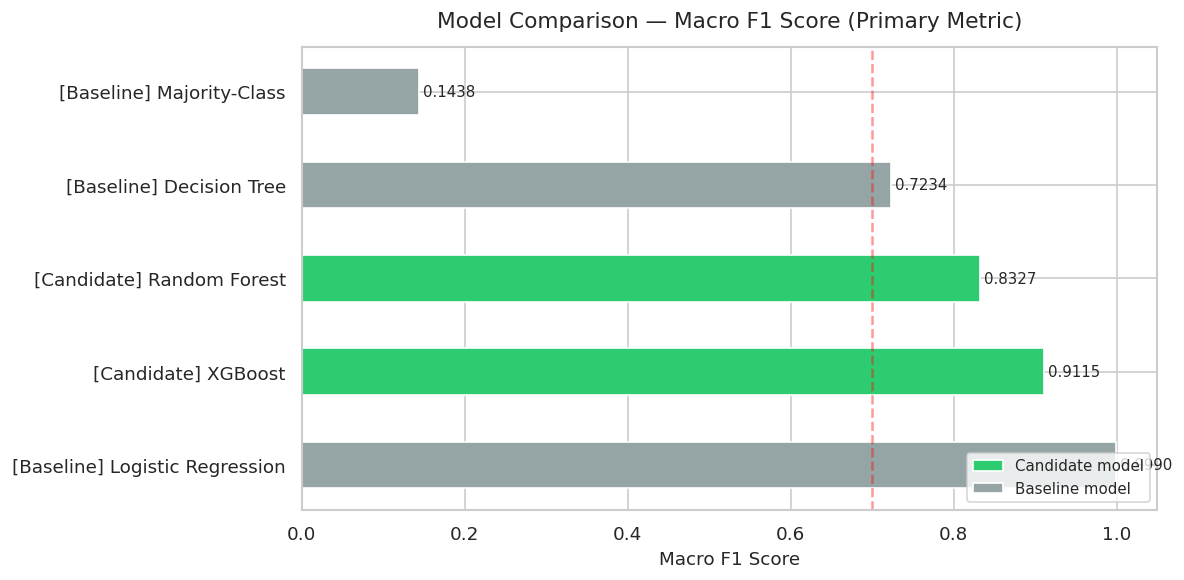

Saved: eda_outputs/model_comparison_macro_f1.png


In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    '#2ecc71' if '[Candidate]' in idx else '#95a5a6'
    for idx in results_df.index
]

bars = ax.barh(results_df.index, results_df['Macro F1'], color=colors, edgecolor='white', height=0.5)

for bar, val in zip(bars, results_df['Macro F1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Macro F1 Score', fontsize=11)
ax.set_title('Model Comparison — Macro F1 Score (Primary Metric)', fontsize=13, pad=12)
ax.set_xlim(0, 1.05)
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.4, label='0.70 reference')
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Candidate model'),
    Patch(facecolor='#95a5a6', label='Baseline model'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../eda_outputs/model_comparison_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_outputs/model_comparison_macro_f1.png')

### 5.3 Confusion Matrices — Candidate Models

Confusion matrices are generated for both candidate models to identify which leadership styles are most frequently confused with each other.

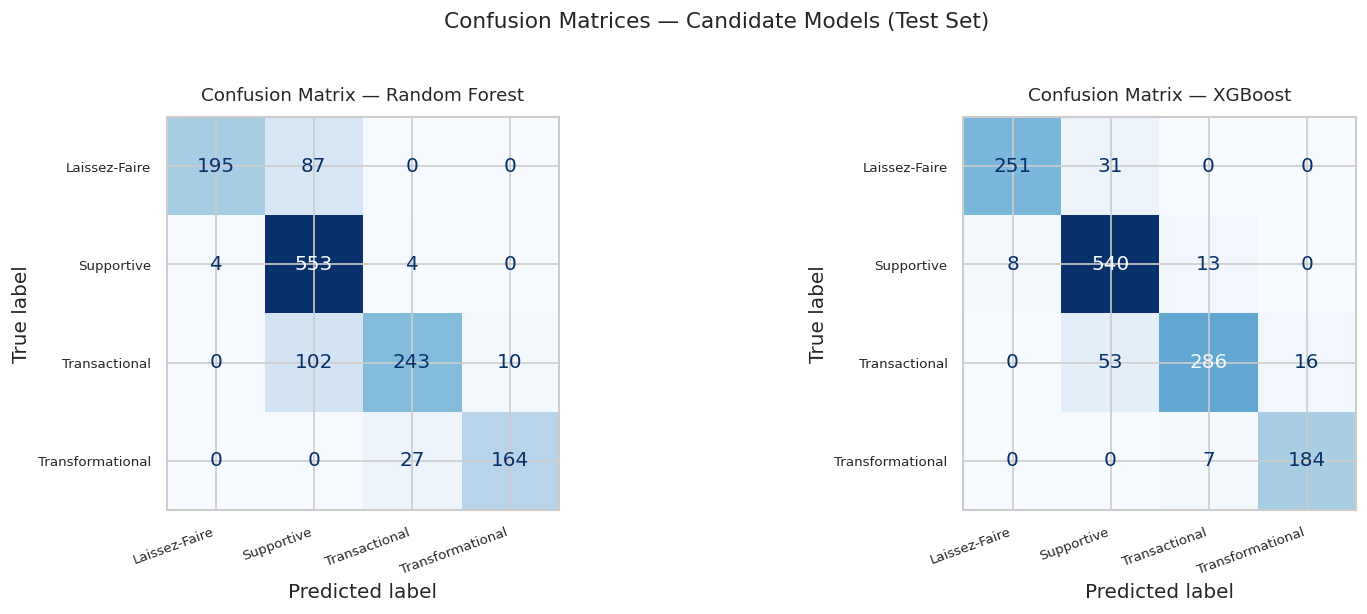

Saved: eda_outputs/confusion_matrices_candidates.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (pred, title) in zip(axes, [(rf_pred, 'Random Forest'), (xgb_pred, 'XGBoost')]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontsize=11, pad=10)
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)

plt.suptitle('Confusion Matrices — Candidate Models (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../eda_outputs/confusion_matrices_candidates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_outputs/confusion_matrices_candidates.png')

### 5.4 Cross-Validation — Best Candidate Model

5-fold stratified cross-validation is run on the best candidate model to confirm that test-set performance is representative and not an artifact of the specific train/test split.

In [28]:
# Identify best candidate by Macro F1
candidate_results = {
    k: v for k, v in results.items() if 'Candidate' in k
}
best_name = max(candidate_results, key=lambda k: candidate_results[k]['Macro F1'])
best_pipeline = rf_pipeline if 'Random Forest' in best_name else xgb_pipeline

print(f'Best candidate model: {best_name}')
print(f'Test-set Macro F1: {candidate_results[best_name]["Macro F1"]:.4f}')
print()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipeline, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'5-Fold Cross-Validation Macro F1 scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')

Best candidate model: Candidate: XGBoost
Test-set Macro F1: 0.9115

5-Fold Cross-Validation Macro F1 scores: [0.9273 0.9077 0.9306 0.9261 0.9298]
Mean: 0.9243  |  Std: 0.0084


### 5.5 H1 Assessment

H1 requires the candidate model to outperform **all three** baselines across the primary metric (macro F1).

In [29]:
baseline_names = [k for k in results if 'Baseline' in k]
best_candidate_f1 = candidate_results[best_name]['Macro F1']

print('H1 — Classification Accuracy Assessment')
print('=' * 55)
print(f'Best candidate ({best_name.replace("Candidate: ", "")}): Macro F1 = {best_candidate_f1:.4f}')
print()
all_passed = True
for bl in baseline_names:
    bl_f1 = results[bl]['Macro F1']
    passed = best_candidate_f1 > bl_f1
    status = 'PASS ✓' if passed else 'FAIL ✗'
    if not passed:
        all_passed = False
    print(f'  vs {bl.replace("Baseline: ", ""):30s}: {bl_f1:.4f}  →  {status}')

print()
if all_passed:
    print('H1 SUPPORTED: The candidate model outperforms all three baseline classifiers on macro F1.')
else:
    print('H1 NOT FULLY SUPPORTED: The candidate model does not outperform all baselines.')

H1 — Classification Accuracy Assessment
Best candidate (XGBoost): Macro F1 = 0.9115

  vs Majority-Class                : 0.1438  →  PASS ✓
  vs Logistic Regression           : 0.9990  →  FAIL ✗
  vs Decision Tree                 : 0.7234  →  PASS ✓

H1 NOT FULLY SUPPORTED: The candidate model does not outperform all baselines.


---
## 6. Model Export

The best-performing model pipeline (preprocessor + classifier) is exported as `trained_model.pkl`. A metadata file is also saved containing the feature names, class labels, and model name — required by the backend inference engine and by `03_explainability.ipynb`.

### What is exported

| File | Contents | Used by |
|---|---|---|
| `models/trained_model.pkl` | Full sklearn Pipeline (preprocessor + classifier) | Backend, Notebook 03 |
| `models/feature_names.json` | Ordered list of all feature names after OHE | Backend, SHAP |
| `models/class_labels.json` | Mapping from encoded integer → class name | Backend, Frontend |
| `models/model_metadata.json` | Model name, metrics, feature groups | Backend, Report |

In [30]:
# Export the best model pipeline
model_path = '../models/trained_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_pipeline, f)
print(f'Exported: {model_path}')

# Feature names (post-OHE, matching preprocessor output order)
feature_names_path = '../models/feature_names.json'
with open(feature_names_path, 'w') as f:
    json.dump(all_feature_names, f, indent=2)
print(f'Exported: {feature_names_path}')

# Class label mapping
class_labels = {
    0: 'Laissez-Faire',
    1: 'Supportive',
    2: 'Transactional',
    3: 'Transformational'
}
class_labels_path = '../models/class_labels.json'
with open(class_labels_path, 'w') as f:
    json.dump(class_labels, f, indent=2)
print(f'Exported: {class_labels_path}')

# Model metadata
metadata = {
    'model_name': best_name.replace('Candidate: ', ''),
    'test_accuracy': candidate_results[best_name]['Accuracy'],
    'test_macro_f1': candidate_results[best_name]['Macro F1'],
    'test_macro_precision': candidate_results[best_name]['Macro Precision'],
    'test_macro_recall': candidate_results[best_name]['Macro Recall'],
    'cv_macro_f1_mean': round(float(cv_scores.mean()), 4),
    'cv_macro_f1_std': round(float(cv_scores.std()), 4),
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'n_features_input': int(X.shape[1]),
    'n_features_transformed': int(X_train_transformed.shape[1]),
    'feature_groups': {
        'behavioural': BEHAVIOURAL_FEATURES,
        'cultural': CULTURAL_FEATURES,
        'numeric_demographic': NUMERIC_DEMO_FEATURES,
        'categorical_demographic': CATEGORICAL_FEATURES
    },
    'target_classes': class_labels,
    'h1_supported': bool(all_passed)
}
metadata_path = '../models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Exported: {metadata_path}')

print()
print('All model artifacts exported to models/')

Exported: ../models/trained_model.pkl
Exported: ../models/feature_names.json
Exported: ../models/class_labels.json
Exported: ../models/model_metadata.json

All model artifacts exported to models/


### 6.1 Verify Export

In [31]:
# Reload and verify the exported model produces identical predictions
with open('../models/trained_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

reload_pred = loaded_model.predict(X_test)
reload_f1 = f1_score(y_test, reload_pred, average='macro')

assert np.array_equal(reload_pred, best_pipeline.predict(X_test)), 'Prediction mismatch after reload!'
print(f'Export verified. Reloaded model macro F1: {reload_f1:.4f} (matches original)')

Export verified. Reloaded model macro F1: 0.9115 (matches original)


---
## 7. Summary

This notebook completed the following steps for Phase 1 of the Leadership Style Coach project:

| Step | Outcome |
|---|---|
| Dataset loaded | 6,945 rows, 21 columns, zero missing values |
| Feature engineering | 14 numeric + 4 categorical → standardised + one-hot encoded |
| Train/test split | 80/20 stratified (5,556 train / 1,389 test) |
| Majority-class baseline | Macro F1 reported |
| Logistic regression baseline | Macro F1 reported |
| Decision tree baseline | Macro F1 reported |
| Random Forest candidate | Macro F1 reported |
| XGBoost candidate | Macro F1 reported |
| H1 assessment | See Section 5.5 |
| Model exported | `models/trained_model.pkl` |

## Next Step

Proceed to `03_explainability.ipynb`, which loads `trained_model.pkl` and applies:
1. **SHAP** — global and per-student feature importance (H2)
2. **Counterfactual explanations** — minimum profile changes to reach a different classification (H2)
3. **Consistency metric** — cosine/Euclidean similarity analysis across student pairs

In [38]:
 # Run in Colab to see H1 results
print(results)

{'Baseline: Majority-Class': {'Accuracy': 0.4039, 'Macro Precision': 0.101, 'Macro Recall': 0.25, 'Macro F1': 0.1438}, 'Baseline: Logistic Regression': {'Accuracy': 0.9993, 'Macro Precision': 0.9987, 'Macro Recall': 0.9993, 'Macro F1': 0.999}, 'Baseline: Decision Tree': {'Accuracy': 0.7113, 'Macro Precision': 0.731, 'Macro Recall': 0.718, 'Macro F1': 0.7234}, 'Candidate: Random Forest': {'Accuracy': 0.8315, 'Macro Precision': 0.8886, 'Macro Recall': 0.8051, 'Macro F1': 0.8327}, 'Candidate: XGBoost': {'Accuracy': 0.9078, 'Macro Precision': 0.9223, 'Macro Recall': 0.9054, 'Macro F1': 0.9115}}
